# Tutorial: A Simple Mamba-Style Block in PyTorch

This notebook builds a small educational **Mamba-style block** from scratch.

It is **not** the full official Mamba implementation. The goal is to understand the core idea:

```text
input token -> create selective SSM parameters -> update hidden state -> output
```

The heart of the block is a recurrent memory update:

```text
new memory = old memory kept or forgotten + new input written into memory
```

In code, that becomes:

```python
h = decay * h + input_to_state
```


## 1. Why Mamba Uses a State Space Model

A sequence model needs a way to remember information from earlier tokens.

Transformers do this with attention: each token can look back at previous tokens.

A state space model, or **SSM**, does something different. It keeps a hidden memory state and updates it as tokens arrive:

```text
h_t = A_t h_{t-1} + B_t x_t
y_t = C_t^T h_t
```

Where:

- `h_t` is the memory after token `t`
- `A_t` controls how much old memory remains
- `B_t` controls how the current token writes into memory
- `C_t` controls how memory is read out
- `y_t` is the output for token `t`

Mamba's key idea is **selectivity**: every input token can create its own memory-control parameters.


## 2. Imports and Reproducibility

We will use only PyTorch. The random seed makes the example output stable enough for learning and debugging.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


torch.manual_seed(42)
print(torch.__version__)

2.12.0


## 3. The Educational Mamba-Style Block

This block has four main pieces:

1. `in_proj` splits the input into a main signal and a gate.
2. `B_proj`, `C_proj`, and `delta_proj` create selective SSM parameters from each token.
3. The loop updates a hidden memory state one token at a time.
4. `out_proj` maps the result back to `d_model`.

Again, this is intentionally simple. Real Mamba implementations use more careful parameterization, convolutional mixing, efficient parallel scan kernels, and hardware-aware optimizations.


In [ ]:
class SimpleMambaBlock(nn.Module):
    def __init__(self, d_model, d_state):
        super().__init__()
        # d_model: input/output dimension
        # d_state: dimension of the SSM state (memory)
        self.d_model = d_model
        self.d_state = d_state

        # Project input into a larger hidden space.
        # The first half will be the main signal, the second half will be a gate.
        self.in_proj = nn.Linear(d_model, d_model * 2)

        # These layers generate selective SSM parameters from the input.
        # In a real implementation, these would be more sophisticated and possibly shared across time steps.
        # For simplicity, we generate B, C, and delta directly from the input at each time step.
        self.B_proj = nn.Linear(d_model, d_state)
        self.C_proj = nn.Linear(d_model, d_state)
        self.delta_proj = nn.Linear(d_model, d_state)

        # Learnable base memory decay.
        self.A_log = nn.Parameter(torch.randn(d_state))

        # Output projection.
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_trace=False):
        """
        x shape: [batch, seq_len, d_model]
        """

        batch_size, seq_len, d_model = x.shape

        # Split into main signal and gate.
        projected = self.in_proj(x)
        x_main, gate = projected.chunk(2, dim=-1)
        gate = torch.sigmoid(gate)

        # Generate input-dependent SSM parameters.
        B = self.B_proj(x_main)              # [batch, seq_len, d_state]
        C = self.C_proj(x_main)              # [batch, seq_len, d_state]
        delta = F.softplus(self.delta_proj(x_main))

        # A controls memory decay. Negative values make exp(delta * A) decay.
        A = -torch.exp(self.A_log)           # [d_state]

        # Hidden state.
        h = torch.zeros(batch_size, self.d_state, device=x.device, dtype=x.dtype)

        outputs = []
        trace = []

        for t in range(seq_len):
            x_t = x_main[:, t, :]            # [batch, d_model]

            B_t = B[:, t, :]                 # [batch, d_state]
            C_t = C[:, t, :]                 # [batch, d_state]
            delta_t = delta[:, t, :]         # [batch, d_state]

            # Discretized decay: how much old memory survives this token.
            decay = torch.exp(delta_t * A)

            # Compress input into state dimension for this toy example.
            input_to_state = B_t * x_t.mean(dim=-1, keepdim=True)

            # Mamba-style memory update:
            # h_t = A_t h_{t-1} + B_t x_t
            h = decay * h + input_to_state

            # Read from state:
            # y_t = C_t^T h_t
            y_t = C_t * h                    # [batch, d_state]

            # Expand back to d_model in a simple educational way.
            y_t = y_t.mean(dim=-1, keepdim=True).repeat(1, d_model)

            outputs.append(y_t)

            if return_trace:
                trace.append({
                    "t": t,
                    "decay_mean": decay.mean().detach().cpu(),
                    "state_norm": h.norm(dim=-1).mean().detach().cpu(),
                    "write_norm": input_to_state.norm(dim=-1).mean().detach().cpu(),
                })

        y = torch.stack(outputs, dim=1)       # [batch, seq_len, d_model]

        # Gate controls what passes through.
        y = y * gate

        y = self.out_proj(y)

        if return_trace:
            return y, trace
        return y

## 4. Run the Block on a Fake Batch

The block preserves the input shape:

```text
[batch, seq_len, d_model] -> [batch, seq_len, d_model]
```


In [3]:
batch_size = 2
seq_len = 8
d_model = 16
d_state = 32

x = torch.randn(batch_size, seq_len, d_model)
block = SimpleMambaBlock(d_model=d_model, d_state=d_state)

y = block(x)

print("input shape: ", x.shape)
print("output shape:", y.shape)

input shape:  torch.Size([2, 8, 16])
output shape: torch.Size([2, 8, 16])


Expected output shape:

```text
torch.Size([2, 8, 16])
```


## 5. Inspect the Memory Update

The most important line is:

```python
h = decay * h + input_to_state
```

Read it as:

```text
new memory = old memory kept/forgotten + new input written into memory
```

The next cell records a tiny trace so we can see how the hidden state evolves across tokens.


In [4]:
with torch.no_grad():
    y, trace = block(x, return_trace=True)

for row in trace:
    print(
        f"t={row['t']:02d} | "
        f"mean decay={row['decay_mean']:.4f} | "
        f"state norm={row['state_norm']:.4f} | "
        f"write norm={row['write_norm']:.4f}"
    )

t=00 | mean decay=0.5027 | state norm=0.5711 | write norm=0.5711
t=01 | mean decay=0.5083 | state norm=0.3703 | write norm=0.2322
t=02 | mean decay=0.5197 | state norm=0.2672 | write norm=0.1031
t=03 | mean decay=0.5226 | state norm=0.3737 | write norm=0.2819
t=04 | mean decay=0.5000 | state norm=0.2709 | write norm=0.1369
t=05 | mean decay=0.5042 | state norm=0.2185 | write norm=0.1159
t=06 | mean decay=0.5266 | state norm=0.2179 | write norm=0.0997
t=07 | mean decay=0.5376 | state norm=0.2378 | write norm=0.1482


## 6. What Makes It Selective?

These lines make the block selective:

```python
B = self.B_proj(x_main)
C = self.C_proj(x_main)
delta = F.softplus(self.delta_proj(x_main))
```

Instead of using one fixed transition for the whole sequence, every token creates its own:

- `B_t`: how strongly this token writes into memory
- `C_t`: how this token reads from memory
- `delta_t`: how quickly memory decays for this token

That is why the update is often written as:

```text
h_t = A_t h_{t-1} + B_t x_t
y_t = C_t^T h_t
```

The uploaded paper describes this selective SSM form and explains that SSMs can be viewed as structured matrix transformations. That viewpoint is the mathematical bridge behind Mamba and Mamba-2.


## 7. A Small Visualization of Memory Growth

This plot is not required for the model. It is just a teaching aid: it shows the average hidden-state norm after each token.


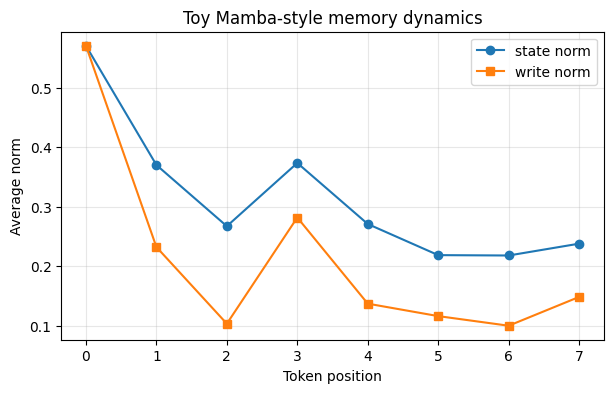

In [5]:
import matplotlib.pyplot as plt

steps = [row["t"] for row in trace]
state_norms = [float(row["state_norm"]) for row in trace]
write_norms = [float(row["write_norm"]) for row in trace]

plt.figure(figsize=(7, 4))
plt.plot(steps, state_norms, marker="o", label="state norm")
plt.plot(steps, write_norms, marker="s", label="write norm")
plt.xlabel("Token position")
plt.ylabel("Average norm")
plt.title("Toy Mamba-style memory dynamics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Key Takeaways

- A Mamba-style block keeps a hidden memory state `h`.
- `decay` decides how much old memory survives.
- `input_to_state` decides what new information gets written.
- `B`, `C`, and `delta` are generated from the input, so the memory behavior is selective.
- Real Mamba implementations make this idea fast and expressive with additional architecture details and optimized kernels.

The core intuition fits in one line:

```python
h = decay * h + input_to_state
```
